In [5]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
root_path = '/Users/brianlerner/Library/CloudStorage/OneDrive-DukeUniversity/Code/ewandi/src'
sys.path.append(root_path)

from server.query import get_schema, get_events
from server import connect_to_collection
from server.retrieve import get_events, get_elements
from utils.general import to_snake_case
import prompts.bio as PROMPTS
import json
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
import numpy as np

from correlation import filter_events, make_cts_df, check_for_correlation, cut_df



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
def plot_data(x1, x2):
    # plot the two vectors using steps and alpha
    plt.step(range(len(x1)), x1, label='x1', alpha=0.5)
    plt.step(range(len(x2)), x2, label='x2', alpha=0.5)
    plt.legend()
    plt.show()

# get events

def get_data_old(days, diff=0, flip=0.2, seed=None):
    # set seed
    if seed is not None:
        np.random.seed(seed)
    d1 = days
    d2 = d1-diff
    # make random vector of 0s and 1s
    x1 = np.random.choice([0, 1], size=d1)
    x2 = x1.copy()
    # randomly flip some of the values in x2
    flip = np.random.choice(range(d1), size=int(flip*days), replace=False)
    x2[flip] = 1-x2[flip]
    # zero out the last d2 values in x2
    x2[d2:] = 0
    return x1,x2

def get_contingency_table(x1, x2):
    table = pd.crosstab(x1, x2)
    # check that all values are greater than 5
    # if table.min().min() < 5:
        # print("Warning: one or more cells have expected frequencies less than 5")
        # print(table)
    return table

# Fisher's exact test

In [4]:
def get_data(days=100, lag=7, flip=0.2, seed=None, event_prob=0.3):
    """Generate data to test correlation functions.

    Keyword Arguments:
        days -- the number of dats to simulate
        flip -- _description_ (default: {0.2})
        seed -- _description_ (default: {None})

    Returns:
        _description_
    """

    # set seed
    if seed is not None:
        np.random.seed(seed)
        
    # make random vector of 0s and 1s to simulate two binary variables
    x1 = np.random.choice([0, 1], size=days+lag, p=[1-event_prob, event_prob])
    # make a copy of x1
    x2 = x1.copy()   

    # now, flip values in x2 randomly
    flip = np.random.choice(range(days), size=int(flip*days), replace=False)
    x2[flip] = 1-x2[flip]

    # now, we pretend that x2 is a copy of x1 subject to a time lag
    if lag:
        x1 = x1[lag:]
        x2 = x2[:-lag]

    return x1,x2

lag = 0
days = 100
# days = 100*24
x1, x2 = get_data(days=days, lag=lag, flip=0.0, seed=None)    
if lag:
    plotx1 = [0]*lag+list(x1)
else:
    plotx1 = x1
plot_data(plotx1, x2)

table = get_contingency_table(x1, x2)
display(table)

sig_stat, p_value = fisher_exact(table, alternative='two-sided')



NameError: name 'plot_data' is not defined

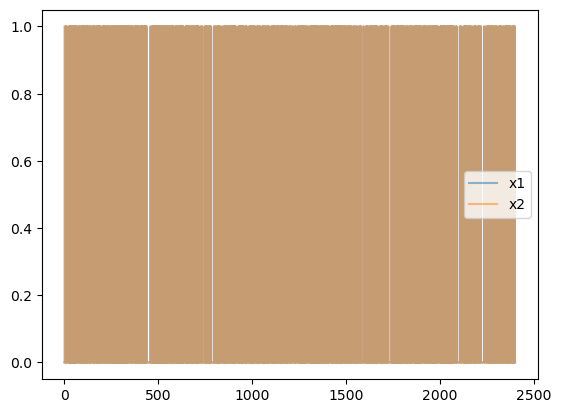

col_0,0,1
row_0,,
0,1183,518
1,517,182


In [147]:
lag = 3
days = 100
days = 100*24
x1, x2 = get_data(days=days, lag=lag, flip=0.0, seed=None)    
if lag:
    plotx1 = [0]*lag+list(x1)
else:
    plotx1 = x1
plot_data(plotx1, x2)

table = get_contingency_table(x1, x2)
display(table)

sig_stat, p_value = fisher_exact(table, alternative='two-sided')

In [151]:


days = 100*24
maxlag = 4*24

# let's test the ability to detect a lag
for flip in [0.0, 0.2, 0.4]:
    print(f"flip: {flip}")
    print()

    for lag in range(0,maxlag):
        # print(f"starting flip: {flip}, lag: {lag}")
        lags = np.arange(0,maxlag)
        # sim data
        x1, x2 = get_data(days=days, lag=lag, flip=flip, seed=None)    

        # try to identify the lag
        p_values = []
        for l in lags:
            # one
            # cx1, cx2 = lag_data(x1, x2, l)
            cx1, cx2 = lag_data(x2, x1, l)
            table = get_contingency_table(cx1, cx2)
            sig_stat, p_value = fisher_exact(table, alternative='two-sided')
            # print(len(cx1), len(cx2))
            # print(f"lag: {lag}, p-value: {p_value:.4f}")
            # plot_data(cx1, cx2)
            # display(table)
            p_values.append(p_value)

        alpha = 0.05
        # get the lags that are significant
        significant_lags = lags[np.array(p_values) < alpha]
        significant_p_values = np.array(p_values)[np.array(p_values) < alpha]

        # sort the lags by p-value
        significant_lags = significant_lags[np.argsort(significant_p_values)]
        # sort the p-values
        significant_p_values = np.sort(significant_p_values).round(4)

        # print(f"significant lags: {significant_lags}")
        # take the first significant lag and check if it is the same as the lag we used to generate the data
        print(f"true lag: {lag}")
        print(f"significant lags: {significant_lags}")
        print(f"significant p-values: {significant_p_values}")
        if len(significant_lags) > 0:
            # get most significant lag (lowest p-value)
            significant_lag = significant_lags[0]
            print(f"lag is the same: {significant_lags[0] == lag}")
            print()
        else:
            print("No significant lags found")


flip: 0.0

true lag: 0
significant lags: [ 0 44 72 66 41 95 39 10 60]
significant p-values: [0.     0.0067 0.0085 0.0226 0.0235 0.0284 0.039  0.0404 0.048 ]
lag is the same: True

true lag: 1
significant lags: [87 20 63 76 50]
significant p-values: [0.0178 0.0219 0.0269 0.03   0.0311]
lag is the same: False

true lag: 2
significant lags: [17 78  9]
significant p-values: [0.0245 0.0259 0.0401]
lag is the same: False

true lag: 3
significant lags: [75 54  6  0]
significant p-values: [0.0408 0.0418 0.0438 0.0439]
lag is the same: False

true lag: 4
significant lags: [43 80 72]
significant p-values: [0.0072 0.0079 0.0161]
lag is the same: False

true lag: 5
significant lags: [8 9]
significant p-values: [0.0096 0.0356]
lag is the same: False

true lag: 6
significant lags: [50 86]
significant p-values: [0.0171 0.0487]
lag is the same: False

true lag: 7
significant lags: [80 51]
significant p-values: [0.0017 0.0338]
lag is the same: False

true lag: 8
significant lags: [79 95 10 75]
signific

# Chi squared

In [8]:
a = np.zeros(100000)
b = a.copy()
table = get_contingency_table(a, b)

# get the chi2 test
chi2, p, dof, ex = chi2_contingency(table)
print("chi2: ", chi2)
print("p: ", p)

chi2:  0.0
p:  1.0


col_0    0   1
row_0         
0      977   4
1      988  31
col_0    0   1
row_0         
0      977   4
1      988  31
col_0    0   1
row_0         
0      977   4
1      988  31
col_0    0   1
row_0         
0      977   4
1      988  31
col_0    0   1
row_0         
0      977   4
1      989  30
col_0    0   1
row_0         
0      977   4
1      989  30
col_0    0   1
row_0         
0      977   4
1      989  30
col_0    0   1
row_0         
0      977   4
1      989  30
col_0    0   1
row_0         
0      977   4
1      989  30
col_0    0   1
row_0         
0      977   4
1      989  30
col_0    0   1
row_0         
0      977   4
1      990  29
col_0    0   1
row_0         
0      977   4
1      990  29
col_0    0   1
row_0         
0      977   4
1      991  28
col_0    0   1
row_0         
0      977   4
1      991  28
col_0    0   1
row_0         
0      977   4
1      991  28
col_0    0   1
row_0         
0      977   4
1      992  27
col_0    0   1
row_0         
0      977

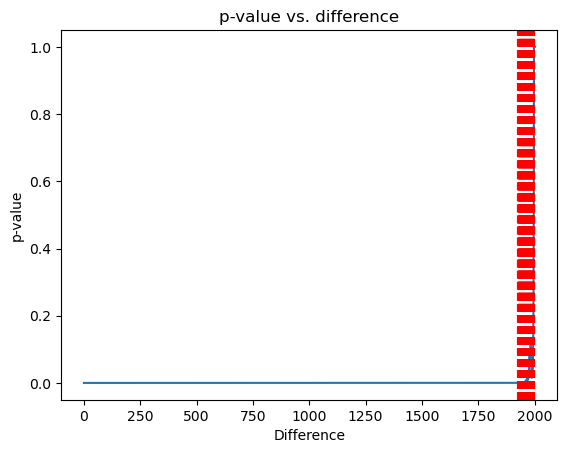

In [9]:
days = 2000
# max_diff = int(days/2)
max_diff = days
p_values = []
diffs = np.arange(1, max_diff+1)
warnings = []
for diff in diffs:
    x1, x2 = get_data(days, diff, seed=0)
    table = get_contingency_table(x1, x2)
    chi2, p, dof, ex = chi2_contingency(table)
    if table.min().min() < 5:
        warnings.append(diff)
    p_values.append(p)
    # print(f"diff: {diff}, p: {p}")
    # plot_data(x1, x2)
    # print(f"diff: {diff}, p: {p}")

plt.plot(diffs, p_values)
# plot vlines at warning diffs
for warning in warnings:
    plt.axvline(x=warning, color='r', linestyle='--')
plt.xlabel('Difference')
plt.ylabel('p-value')
plt.title('p-value vs. difference')
# draw a horizontal line at 0.05
# plt.axhline(y=0.05, color='r', linestyle='-')
plt.show()

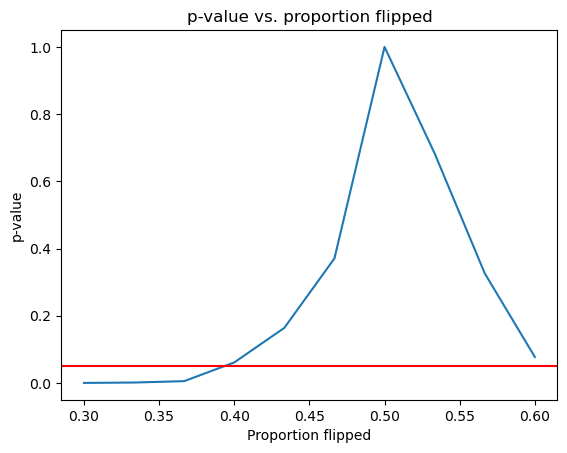

In [71]:
# now let's look at the effect of flipping some of the values
p_values = []
flips = np.linspace(0.3,0.6,10)
for flip in flips:
    x1, x2 = get_data(days, 0, flip)
    table = get_contingency_table(x1, x2)
    chi2, p, dof, ex = chi2_contingency(table)
    p_values.append(p)
    # print(f"flip: {flip}, p: {p}")

plt.plot(flips, p_values)
plt.xlabel('Proportion flipped')
plt.ylabel('p-value')
plt.title('p-value vs. proportion flipped')
# draw a line at 0.05
plt.axhline(y=0.05, color='r', linestyle='-')
plt.show()


## Next thing to do: investigate measuring lag
- try to do this for days, hours, minutes
- could rule out lags that don't meet minimum number for test...

# Testing lags

In [50]:
cts_df

,onions
2023-09-01,3
2023-09-02,2
2023-09-03,3
2023-09-04,3
2023-09-05,3
...,...
2023-12-26,3
2023-12-27,2
2023-12-28,2
2023-12-29,3


In [62]:
# v1,v2 = "basketball practice", "shoulder pain"
# v1,v2 = "elbow pain", "homework due: Computer Programming"
v1, v2 = 'stomachache', 'onions'
v1_events = filter_events(v1)
v2_events = filter_events(v2)
all_events = v1_events + v2_events
cts_df = make_cts_df(all_events, cap=True)
x1 = cts_df.iloc[:,0]
x2 = cts_df.iloc[:,1]

In [65]:
cts_df

,stomachache,onions
2023-09-02,1,1
2023-09-03,0,1
2023-09-04,0,1
2023-09-05,1,1
2023-09-06,1,1
...,...,...
2023-12-26,0,1
2023-12-27,0,1
2023-12-28,0,1
2023-12-29,0,1


In [64]:
x1 = list(x1)
x2 = list(x2)
if lag:
    x1, x2 = lag_data(x1, x2, lag)
x1 = pd.Categorical(x1, categories=[0, 1])
x2 = pd.Categorical(x2, categories=[0, 1])
table = pd.crosstab(x1, x2, dropna=False)
table

col_0,0,1
row_0,,
0,0,70
1,0,50


In [67]:
# now, we want to know if there's a significant correlation without any lag
check_for_correlation(x1,x2, lag=0)

col_0  0   1
row_0       
0      0  70
1      0  50
p-value: 1.0


1.0

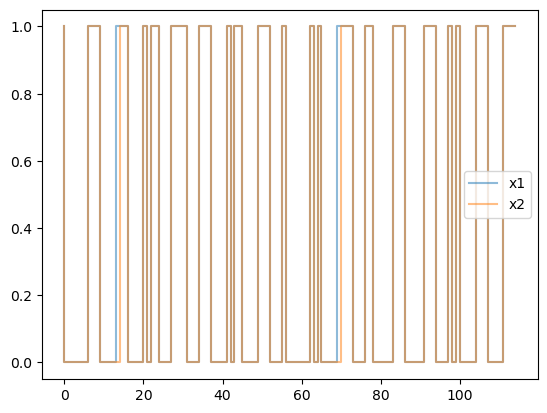

In [198]:
def lag_data(x1, x2, lag):
    if lag:
        x1 = x1[:-lag]
        x2 = x2[lag:]
    return x1, x2

cx1, cx2 = lag_data(x1, x2, 0)
plot_data(cx1, cx2)

In [229]:
from llm.my_tools.plotting import plot_single_event_count

plot_single_event_count(v1_events+v2_events)

/Users/brianlerner/miniconda3/envs/c5/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [158]:
all_events = v1_events + v2_events


In [34]:
    # get contingency table
    table = get_contingency_table(day_counts['v1'], day_counts['v2'])

datetime.date(2023, 9, 4)

# Calculate the non-lagged day to day correlation between one variable and all other variables

In [12]:
# get all the events in the dataset
events = get_events()
# make a new column that contains the name (category) (parent_name)
# d['cname'] = d.apply(lambda x: f"{x['name']} ({x['category']}) ({x['parent_name']})", axis=1)
# check_for_correlation(x1,x2, lag=0)
for i, e in enumerate(events):
    e['cname'] = f"{e['name']} ({e['category']}) ({e['parent_name']})"

d = pd.DataFrame(events)


In [39]:
cts_df

,stomachache,olives
2023-09-02,1,1
2023-09-03,0,2
2023-09-04,0,2
2023-09-05,1,2
2023-09-06,1,1
...,...,...
2023-12-26,0,2
2023-12-27,0,1
2023-12-28,0,1
2023-12-29,0,2


In [70]:
name = 'stomachache'
chosen_cname = d[d['name'] == name].cname.values[0]
dtype = d[d['name'] == name].dtype.values[0]


# get a list of all other cnames
# filter out all events that dont have the matching dtype
other_d = d[(d.dtype == dtype) & (d.cname != chosen_cname)]

# if (other_d.dtype == 'binary').all().all():


other_cnames = other_d.cname.unique()

# get the cname cts
print(other_cnames.shape)


v1_events = filter_events(chosen_cname, col='cname', events=events)
p_values = []
for other_cname in other_cnames:
    print(other_cname)
    v2_events = filter_events(other_cname, col='cname', events=events)
    cts_df = make_cts_df(v1_events + v2_events, cap=True)
    # if any counts are greater than 1, make 1
    p_value = check_for_correlation(cts_df.iloc[:,0], cts_df.iloc[:,1], lag=0)
    p_values.append(p_value)


(46,)
headache (sensation) (None)
col_0   0   1
row_0        
0      42  28
1      30  19
p-value: 1.0
eggs (food) (dietary intake)
col_0   0   1
row_0        
0      25  45
1      19  31
p-value: 0.8488599424880756
spinach (food) (dietary intake)
col_0   0   1
row_0        
0      25  45
1      19  31
p-value: 0.8488599424880756
olives (food) (dietary intake)
col_0  0   1
row_0       
0      0  70
1      0  50
p-value: 1.0
feta cheese (food) (dietary intake)
col_0  0   1
row_0       
0      0  70
1      0  50
p-value: 1.0
tomatoes (food) (dietary intake)
col_0  0   1
row_0       
0      0  70
1      0  50
p-value: 1.0
bell peppers (food) (dietary intake)
col_0  0   1
row_0       
0      0  70
1      0  50
p-value: 1.0
onions (food) (dietary intake)
col_0  0   1
row_0       
0      0  70
1      0  50
p-value: 1.0
garlic (food) (dietary intake)
col_0  0   1
row_0       
0      0  70
1      0  50
p-value: 1.0
avocado (food) (dietary intake)
col_0   0   1
row_0        
0      25  45
1    

In [45]:
p_values.shape

(46,)

In [72]:
p_values = np.array(p_values)
significant = p_values < 0.05

pdf = pd.DataFrame({'cname': other_cnames, 'p-value': p_values, 'significant': significant})

pdf =  pdf.sort_values('p-value')

filtered_pdf = pdf[pdf.significant]
filtered_pdf

,cname,p-value,significant
41,basketball game (activity) (None),0.014655,True
29,talking on the phone (activity) (None),0.040922,True


In [ ]:
# for those that are significant, repeat the process with a 

# Establish schema

In [63]:
# this may not be usefull..
link_rules = {
        'calendar_events':{
            'datatype': 'binary', # include here?
            'caused': False,
        }
        # 'activities':{
        #     'datatype': 'binary', # include here?
        #     'no_forward_link': ['calendar_events'],
        # }
    }

def get_permutations(variables):

    schema = get_schema()
    def link_filter(x, y):
        # x = cause, y = effect
        if x in schema:
            x_cat = schema[x]
        else:
            raise ValueError(f'{x} not found in schema')
        if y in schema:
            y_cat = schema[y]
        else:
            raise ValueError(f'{y} not found in schema')
        
        if y_cat in link_rules:
            return link_rules[y_cat].get("caused", True)
        else:
            return True

        # if x_cat in link_rules:
        #     if link_rules[x_cat].get("no_backward_link", False):
        #         return False
        # elif y_cat in link_rules:
        #     print(x,y)

        #     if link_rules[y_cat].get("no_forward_link", False):
        #         return False
        # else:
        #     return True

    from itertools import permutations
    # Finding all combinations of two variables where order matters
    permutations = [pair for pair in permutations(variables, 2) if link_filter(*pair)]
    return permutations

permutations = get_permutations(schema.keys())
len(permutations), permutations

(6,
 [('Basketball Game', 'elbow pain'),
  ('Computer Programming', 'elbow pain'),
  ('Basketball Practice', 'elbow pain'),
  ('Discrete Mathematics', 'elbow pain'),
  ('Discrete Mathematics HW due', 'elbow pain'),
  ('Computer Programming HW due', 'elbow pain')])

In [38]:
import time
def measure_causality(cause, effect):
    system_prompt = f"""You are a utility that determines the potential causality between two variables. These variables come from an indivdual's life as described in this bio:

    {bio}

    When the two variables are provided, they will be words or phrases and be comma-separated. Assume that the first variable is the potential cause and the second variable is the potential effect. They
    please determine the strength of causality from 1-5, with 1 being the weakest and 5 being the strongest. 
    If you are unsure, please say so by outputting a 0.
    Also, please provide a short explanation for your answer.
    When requested, return the requested information as a JSON object with the keys "causality_score" and "explanation".
    """

    # print(system_prompt)
    conversation = Conversation(first_message = ("system", system_prompt))
    conversation.add_message("user", f"Please find the causality between: {cause}, {effect}")

    start = time.time()
    response = chat_completion_request(conversation, model=GPT_MODEL, stream=False, response_format={"type":"json_object"})
    end = time.time()
    # response = get_completion(conversation.messages, model=GPT_MODEL,response_format={"type":"json_object"})
    json_response = response.choices[0].message.content 

    try:
        full_response = json.loads(json_response)
        if "causality_score" not in full_response:
            causality_score = f"Error: causality_score not found in response. Response: {full_response}"
        else:
            causality_score = full_response["causality_score"]
        if "explanation" not in full_response:
            explanation = f"Error: explanation not found in response. Response: {full_response}"
        else:
            explanation = full_response["explanation"]
    except Exception as e:
        print(e)
        print(json_response)
        causality_score = None
        explanation = e
        runtime=None
    
    return {'causality_score':causality_score, 'explanation':explanation, 'runtime':end-start}


In [65]:
pd.set_option('display.max_colwidth', None)

def create_causality_cols(x):
    c_info = measure_causality(x.cause, x.effect)
    return pd.Series(list(c_info.values()))

perm_df = pd.DataFrame(permutations, columns=["cause", "effect"])#.iloc[0:10]
perm_df[['causality_score', 'explanation', 'runtime']] = perm_df.apply(create_causality_cols, axis=1)
perm_df


,cause,effect,causality_score,explanation,runtime
0,Basketball Game,elbow pain,4,"There is a strong causality between playing basketball games and experiencing elbow pain, as the physical demands of the game, such as shooting, dribbling, and defending, can put strain on the elbow joint and surrounding muscles, potentially leading to pain or injury.",1.650221
1,Computer Programming,elbow pain,3,"There is a moderate strength causality between computer programming and elbow pain. Prolonged computer use and poor ergonomics can lead to repetitive strain injuries, including elbow pain. However, individual factors and behaviors also play a role in the development of elbow pain.",1.525373
2,Basketball Practice,elbow pain,4,"Basketball practice can involve repetitive motions and physical exertion, which can lead to overuse injuries such as elbow pain. The nature of the sport and the strain it puts on the body make it highly likely that basketball practice could cause elbow pain.",1.433934
3,Discrete Mathematics,elbow pain,0,There is no direct causal relationship between studying Discrete Mathematics and experiencing elbow pain. These two variables are unlikely to have a direct impact on each other.,1.126409
4,Discrete Mathematics HW due,elbow pain,3,"There is a moderate causality between Discrete Mathematics HW due and elbow pain. It is possible that the stress of approaching deadlines and prolonged sitting while working on the homework could contribute to the development of elbow pain, especially if the individual is not mindful of their posture.",1.696662
5,Computer Programming HW due,elbow pain,3,"There is a moderate causality between Computer Programming HW due and elbow pain. Prolonged computer use and typing can lead to strain on the elbow and arm muscles, potentially resulting in pain or discomfort.",1.374528


Ok, now time to figure out the correlations.
For now, let's only apply correlation to things that are valid causally.

In [99]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests, ccf
from datetime import datetime, timedelta

# Example list of dictionaries
events = x_events+ y_events

# Convert to DataFrame
df = pd.DataFrame(events)
df = df[['name','start_datetime', 'end_datetime']]
df

,name,start_datetime,end_datetime
0,Basketball Game,2023-09-01 19:00:00,2023-09-01 22:00:00
1,Basketball Game,2023-09-08 19:00:00,2023-09-08 22:00:00
2,Basketball Game,2023-09-15 19:00:00,2023-09-15 22:00:00
3,Basketball Game,2023-09-22 19:00:00,2023-09-22 22:00:00
4,Basketball Game,2023-09-29 19:00:00,2023-09-29 22:00:00
5,Basketball Game,2023-10-06 19:00:00,2023-10-06 22:00:00
6,Basketball Game,2023-10-13 19:00:00,2023-10-13 22:00:00
7,Basketball Game,2023-10-20 19:00:00,2023-10-20 22:00:00
8,Basketball Game,2023-10-27 19:00:00,2023-10-27 22:00:00
9,Basketball Game,2023-11-03 19:00:00,2023-11-03 22:00:00



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2820  , p=0.5955  , df_denom=2856, df_num=1
ssr based chi2 test:   chi2=0.2822  , p=0.5952  , df=1
likelihood ratio test: chi2=0.2822  , p=0.5952  , df=1
parameter F test:         F=0.2820  , p=0.5955  , df_denom=2856, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2028  , p=0.8165  , df_denom=2853, df_num=2
ssr based chi2 test:   chi2=0.4063  , p=0.8162  , df=2
likelihood ratio test: chi2=0.4063  , p=0.8162  , df=2
parameter F test:         F=0.2028  , p=0.8165  , df_denom=2853, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.2077  , p=0.8911  , df_denom=2850, df_num=3
ssr based chi2 test:   chi2=0.6247  , p=0.8907  , df=3
likelihood ratio test: chi2=0.6247  , p=0.8908  , df=3
parameter F test:         F=0.2077  , p=0.8911  , df_denom=2850, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.2634  , p=0.

/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/3919270926.py:33: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



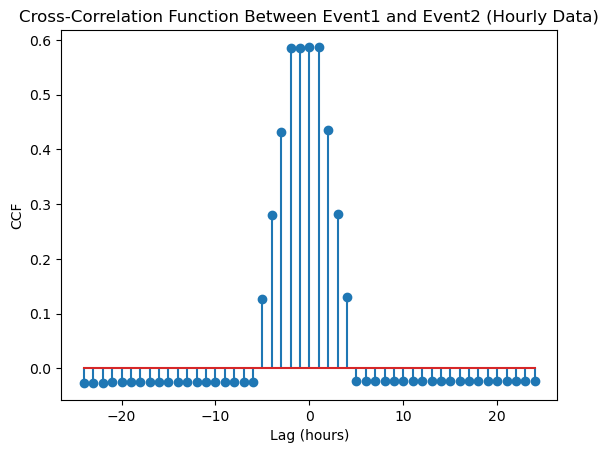

In [143]:

names = df.name.unique()

# Convert datetime strings to datetime objects
df['start_datetime'] = pd.to_datetime(df['start_datetime'])
df['end_datetime'] = pd.to_datetime(df['end_datetime'])

# Resample to a consistent time interval (e.g., hourly)
start = df['start_datetime'].min().floor('H')
end = df['end_datetime'].max().ceil('H')
time_index = pd.date_range(start=start, end=end, freq='H')

# Create time series for each event type
series_a = pd.Series(0, index=time_index)
series_b = pd.Series(0, index=time_index)

# Populate the series based on events
for _, row in df.iterrows():
    if row['name'] == names[0]:
        series_a[row['start_datetime']:row['end_datetime']] = 1
    elif row['name'] == names[1]:
        series_b[row['start_datetime']:row['end_datetime']] = 1

# Ensure same length
length = min(len(series_a), len(series_b))
series_a = series_a[:length]
series_b = series_b[:length]

maxlag = 24
# Granger Causality Test
gc_result = grangercausalitytests(pd.DataFrame({names[0]: series_a, names[1]: series_b}), maxlag=maxlag)

# Cross-Correlation Function
ccf_vals = ccf(series_a, series_b, unbiased=True)

# # Print CCF results (example for first 10 lags)
# print("CCF Results (first 10 lags):")
# for lag in range(10):
#     print(f"Lag {lag}: {ccf_result[lag]}")

# # Granger Causality Test
# max_lag_hrs = 12 # Define max lag (days)
# gc_test = grangercausalitytests(pd.concat([df_event1, df_event2], axis=1), maxlag=max_lag_hrs)

# # Assuming df_event1 and df_event2 are resampled to hourly data

# # max_lag_hours = 24  # Define max lag in hours
lags = range(-maxlag, maxlag + 1)


# ccf_vals = ccf(df_event1, df_event2, unbiased=True)



# Make sure that the length of 'lags' and 'ccf_vals' is the same
min_length = min(len(lags), len(ccf_vals))
lags = lags[:min_length]
ccf_vals = ccf_vals[:min_length]

# Plotting the CCF
plt.stem(lags, ccf_vals)
plt.title('Cross-Correlation Function Between Event1 and Event2 (Hourly Data)')
plt.xlabel('Lag (hours)')
plt.ylabel('CCF')
plt.show()




In [140]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests, ccf
import matplotlib.pyplot as plt


df['start_datetime'] = pd.to_datetime(df['start_datetime'])
df['date'] = df['start_datetime'].dt.date

# Create time series for each event
df_event1 = df[df['name'] == names[0]].groupby('date').size().reindex(pd.date_range(df['date'].min(), df['date'].max(), freq='H'), fill_value=0)
df_event2 = df[df['name'] == names[1]].groupby('date').size().reindex(pd.date_range(df['date'].min(), df['date'].max(), freq='H'), fill_value=0)


In [113]:
df_event1.shape

(2857,)

In [121]:
df

,name,start_datetime,end_datetime,date
0,Basketball Game,2023-09-01 19:00:00,2023-09-01 22:00:00,2023-09-01
1,Basketball Game,2023-09-08 19:00:00,2023-09-08 22:00:00,2023-09-08
2,Basketball Game,2023-09-15 19:00:00,2023-09-15 22:00:00,2023-09-15
3,Basketball Game,2023-09-22 19:00:00,2023-09-22 22:00:00,2023-09-22
4,Basketball Game,2023-09-29 19:00:00,2023-09-29 22:00:00,2023-09-29
5,Basketball Game,2023-10-06 19:00:00,2023-10-06 22:00:00,2023-10-06
6,Basketball Game,2023-10-13 19:00:00,2023-10-13 22:00:00,2023-10-13
7,Basketball Game,2023-10-20 19:00:00,2023-10-20 22:00:00,2023-10-20
8,Basketball Game,2023-10-27 19:00:00,2023-10-27 22:00:00,2023-10-27
9,Basketball Game,2023-11-03 19:00:00,2023-11-03 22:00:00,2023-11-03



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0669  , p=0.7960  , df_denom=2853, df_num=1
ssr based chi2 test:   chi2=0.0669  , p=0.7959  , df=1
likelihood ratio test: chi2=0.0669  , p=0.7959  , df=1
parameter F test:         F=0.0669  , p=0.7960  , df_denom=2853, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0679  , p=0.9344  , df_denom=2850, df_num=2
ssr based chi2 test:   chi2=0.1360  , p=0.9343  , df=2
likelihood ratio test: chi2=0.1360  , p=0.9343  , df=2
parameter F test:         F=0.0679  , p=0.9344  , df_denom=2850, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0689  , p=0.9765  , df_denom=2847, df_num=3
ssr based chi2 test:   chi2=0.2072  , p=0.9764  , df=3
likelihood ratio test: chi2=0.2072  , p=0.9764  , df=3
parameter F test:         F=0.0689  , p=0.9765  , df_denom=2847, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.0700  , p=0.

/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/4124203833.py:10: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



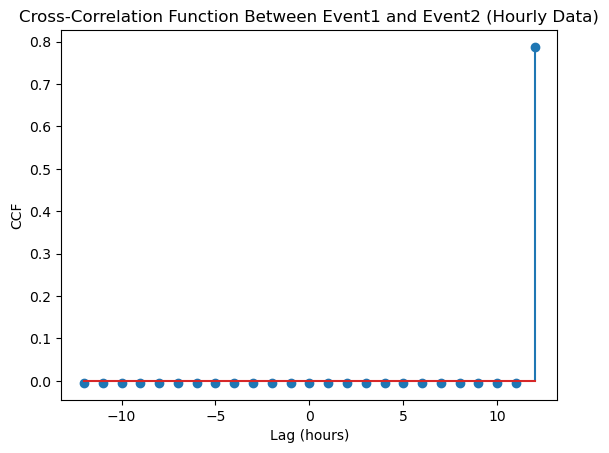

In [122]:
# Granger Causality Test
max_lag_hrs = 12 # Define max lag (days)
gc_test = grangercausalitytests(pd.concat([df_event1, df_event2], axis=1), maxlag=max_lag_hrs)

# Assuming df_event1 and df_event2 are resampled to hourly data

# max_lag_hours = 24  # Define max lag in hours
lags = range(-max_lag_hrs, max_lag_hrs + 1)

ccf_vals = ccf(df_event1, df_event2, unbiased=True)

# Make sure that the length of 'lags' and 'ccf_vals' is the same
min_length = min(len(lags), len(ccf_vals))
lags = lags[:min_length]
ccf_vals = ccf_vals[:min_length]

# Plotting the CCF
plt.stem(lags, ccf_vals)
plt.title('Cross-Correlation Function Between Event1 and Event2 (Hourly Data)')
plt.xlabel('Lag (hours)')
plt.ylabel('CCF')
plt.show()



In [133]:
for i in df_event1:
    print(i)

1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [125]:
df_event2[df_event2 > 0]

2023-09-14    1
2023-09-28    1
2023-10-05    1
2023-10-19    1
2023-10-26    1
2023-11-02    1
2023-11-09    1
2023-11-30    1
2023-12-07    1
2023-12-14    1
2023-12-28    1
dtype: int64

range(-7, 8)

In [118]:
# Cross-Correlation Function
lags = range(-max_lag, max_lag + 1)
ccf_vals = ccf(df_event1, df_event2, unbiased=True)
ccf_vals.shape


/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/3082671451.py:3: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



(2857,)

In [ ]:

# Plotting the CCF
plt.stem(lags, ccf_vals)
plt.title('Cross-Correlation Function Between Event1 and Event2')
plt.xlabel('Lag (days)')
plt.ylabel('CCF')
plt.show()


# CCF

/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/140677489.py:13: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



ValueError: could not broadcast input array from shape (217,) into shape (20,)

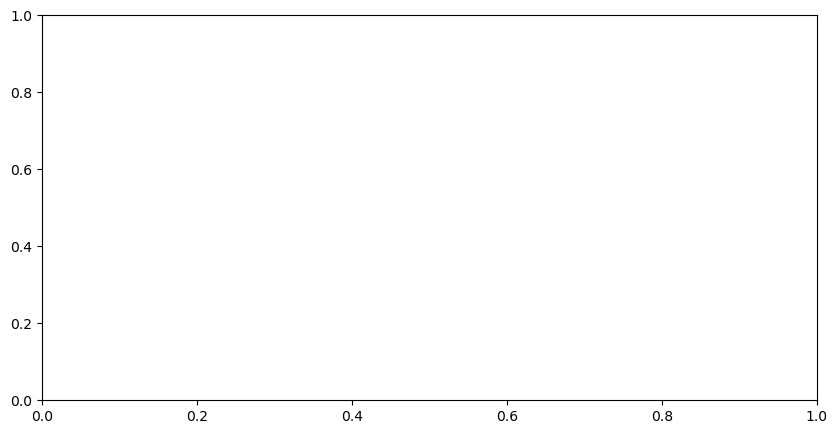

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# Generate sample data
np.random.seed(0)  # For reproducibility
hours = pd.date_range(start='2021-01-01', end='2021-01-10', freq='H')
series_A = np.random.rand(len(hours))  # Random data for Series A
series_B = np.roll(series_A, shift=3)  # Series B is Series A shifted by 3 hours

# Apply CCF
ccf_vals = ccf(series_A, series_B, unbiased=True)


max_lag = 10
# Plotting the CCF
lags = range(-max_lag, max_lag)
plt.figure(figsize=(10, 5))
plt.stem(lags, ccf_vals)
plt.title('Cross-Correlation Function Between Series A and B')
plt.xlabel('Lag (hours)')
plt.ylabel('CCF')
plt.xlim(-48, 48)  # Limiting x-axis to +/- 48 hours for clarity
plt.show()


/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/3768808779.py:11: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



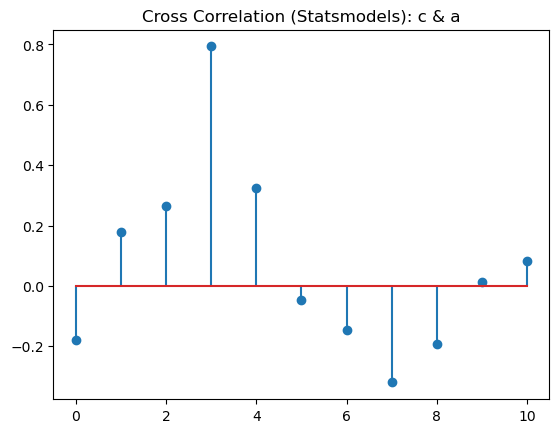

In [152]:
points = 50
a = np.random.rand(points)
b = np.random.rand(points)
data = pd.DataFrame({"a":a, "b": b})
data["c"] = data["a"].shift(3) + data["b"].shift(1)
data.shape, data.columns
data.dropna(inplace=True)


/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/3819410628.py:3: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



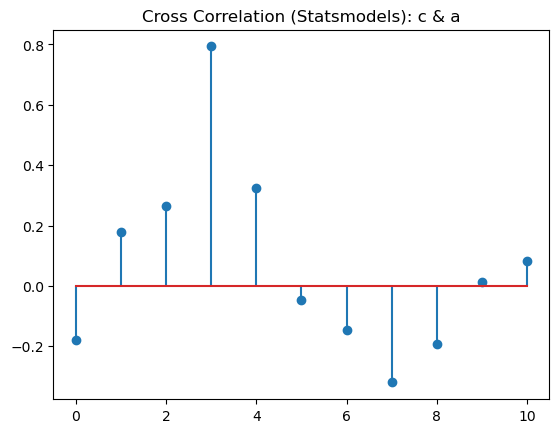

In [153]:

def plot_ccf_sm(target, exog, unbiased=False, nlags=10):
    """Plot CCF using Statsmodels"""
    ccfs = ccf(target, exog, unbiased=False)[:nlags+1]
    lags = np.arange(len(ccfs))[:nlags+1]
    _ = plt.stem(lags, ccfs)
    _ = plt.title(f"Cross Correlation (Statsmodels): {target.name} & {exog.name}")

plot_ccf_sm(data["c"], data["a"])

# Old

In [66]:
causal_threshold = 3
causal_df = perm_df[perm_df.causality_score >= causal_threshold]
causal_df

,cause,effect,causality_score,explanation,runtime
0,Basketball Game,elbow pain,4,"There is a strong causality between playing basketball games and experiencing elbow pain, as the physical demands of the game, such as shooting, dribbling, and defending, can put strain on the elbow joint and surrounding muscles, potentially leading to pain or injury.",1.650221
1,Computer Programming,elbow pain,3,"There is a moderate strength causality between computer programming and elbow pain. Prolonged computer use and poor ergonomics can lead to repetitive strain injuries, including elbow pain. However, individual factors and behaviors also play a role in the development of elbow pain.",1.525373
2,Basketball Practice,elbow pain,4,"Basketball practice can involve repetitive motions and physical exertion, which can lead to overuse injuries such as elbow pain. The nature of the sport and the strain it puts on the body make it highly likely that basketball practice could cause elbow pain.",1.433934
4,Discrete Mathematics HW due,elbow pain,3,"There is a moderate causality between Discrete Mathematics HW due and elbow pain. It is possible that the stress of approaching deadlines and prolonged sitting while working on the homework could contribute to the development of elbow pain, especially if the individual is not mindful of their posture.",1.696662
5,Computer Programming HW due,elbow pain,3,"There is a moderate causality between Computer Programming HW due and elbow pain. Prolonged computer use and typing can lead to strain on the elbow and arm muscles, potentially resulting in pain or discomfort.",1.374528


In [67]:
causal_df.at[1, 'cause'] = 'elbow pain'
causal_df.at[1, 'effect'] = 'Basketball Game'

In [68]:
causal_df

,cause,effect,causality_score,explanation,runtime
0,Basketball Game,elbow pain,4,"There is a strong causality between playing basketball games and experiencing elbow pain, as the physical demands of the game, such as shooting, dribbling, and defending, can put strain on the elbow joint and surrounding muscles, potentially leading to pain or injury.",1.650221
1,elbow pain,Basketball Game,3,"There is a moderate strength causality between computer programming and elbow pain. Prolonged computer use and poor ergonomics can lead to repetitive strain injuries, including elbow pain. However, individual factors and behaviors also play a role in the development of elbow pain.",1.525373
2,Basketball Practice,elbow pain,4,"Basketball practice can involve repetitive motions and physical exertion, which can lead to overuse injuries such as elbow pain. The nature of the sport and the strain it puts on the body make it highly likely that basketball practice could cause elbow pain.",1.433934
4,Discrete Mathematics HW due,elbow pain,3,"There is a moderate causality between Discrete Mathematics HW due and elbow pain. It is possible that the stress of approaching deadlines and prolonged sitting while working on the homework could contribute to the development of elbow pain, especially if the individual is not mindful of their posture.",1.696662
5,Computer Programming HW due,elbow pain,3,"There is a moderate causality between Computer Programming HW due and elbow pain. Prolonged computer use and typing can lead to strain on the elbow and arm muscles, potentially resulting in pain or discomfort.",1.374528


In [78]:

def get_combinations(df):
    # Finding unique combinations where (x,y) is considered the same as (y,x)
    unique_combinations = set()

    for row in df.itertuples(index=False):
        x, y = row
        unique_combinations.add(tuple(sorted([x, y])))

    # Convert the set to a list for better readability
    unique_combinations_list = list(unique_combinations)
    return sorted(unique_combinations_list, key=lambda x: x[0])
combinations = get_combinations(causal_df[["cause", "effect"]])

In [81]:
# retrieve_events(closest_variable_name, conditions=conditions)
# events
for x,y in combinations[0:1]:
    x_events = retrieve_events(x)
    y_events = retrieve_events(y)


In [89]:
def plot_events(events):

    import plotly.express as px 

    # Convert the data to a DataFrame
    df = pd.DataFrame(events) 

    # Map each event type to a unique integer
    event_type_mapping = {event: i+1 for i, event in enumerate(df['name'].unique())}
    df['event_type_id'] = df['name'].map(event_type_mapping)

    # Plotting using Plotly
    fig = px.scatter(df, x='start_datetime', y='event_type_id', color='name', title='Event Schedule')
    fig.update_layout(xaxis_title='Date', yaxis_title='Event Type', yaxis=dict(tickmode='array', tickvals=list(event_type_mapping.values()), ticktext=list(event_type_mapping.keys())))
    fig.show()

plot_events(y_events+ x_events)

In [91]:
events_df = pd.DataFrame(x_events)
events_df

,name,id,group,location,description,start_datetime,end_datetime
0,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-01 19:00:00,2023-09-01 22:00:00
1,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-08 19:00:00,2023-09-08 22:00:00
2,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-15 19:00:00,2023-09-15 22:00:00
3,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-22 19:00:00,2023-09-22 22:00:00
4,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-29 19:00:00,2023-09-29 22:00:00
5,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-10-06 19:00:00,2023-10-06 22:00:00
6,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-10-13 19:00:00,2023-10-13 22:00:00
7,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-10-20 19:00:00,2023-10-20 22:00:00
8,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-10-27 19:00:00,2023-10-27 22:00:00
9,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-11-03 19:00:00,2023-11-03 22:00:00


In [ ]:
import scipy.stats as stats

# Calculating Spearman's correlation
correlation, p_value = stats.spearmanr(worked_out, felt_good)

print(f"Correlation Coefficient: {correlation}")
print(f"P-value: {p_value}")


In [84]:
pd.DataFrame(x_events).start_datetime

0    2023-09-01 19:00:00
1    2023-09-08 19:00:00
2    2023-09-15 19:00:00
3    2023-09-22 19:00:00
4    2023-09-29 19:00:00
5    2023-10-06 19:00:00
6    2023-10-13 19:00:00
7    2023-10-20 19:00:00
8    2023-10-27 19:00:00
9    2023-11-03 19:00:00
10   2023-11-10 19:00:00
11   2023-11-17 19:00:00
12   2023-11-24 19:00:00
13   2023-12-01 19:00:00
14   2023-12-08 19:00:00
15   2023-12-15 19:00:00
16   2023-12-22 19:00:00
17   2023-12-29 19:00:00
Name: start_datetime, dtype: datetime64[ns]

In [69]:
unique_pairs = causal_df[['cause', 'effect']].drop_duplicates()
unique_pairs


,cause,effect
0,Basketball Game,elbow pain
1,elbow pain,Basketball Game
2,Basketball Practice,elbow pain
4,Discrete Mathematics HW due,elbow pain
5,Computer Programming HW due,elbow pain


In [18]:
conversation.messages.append({"role": "user", "content": prompt})

v1 = 'elbow pain'
v2 = 'Basketball Practice'

prompt = f"""Consider the following two phrases:
1. {v1}
2. {v2}
"""
prompt

'Consider the following two phrases:\n1. elbow pain\n2. Basketball Practice\n'

# I'll want to convert all of the labesl to snake case

In [83]:
# elbow pain.intensity should be valid (make sure to convert all to snake case and remove periods when comparing)
rel_dict_template = {'x':{
        'reps': {
            'binary':{
                'rel_with':
                    {
                        'y':{
                            'reps':{
                                'binary':{
                                    'valid': True,
                                    'caus':
                                        {
                                            'value': 4,
                                            'method':'LLM'

                                        },
                                    'corr':{
                                        'timescale':{
                                            'D':{
                                                'full_range':{
                                                    'corr':
                                                        {
                                                            'value': 2,
                                                            'method': 'spearman'
                                                        }
                                                }}}
                                    }
                                }
                    }
            }}
        }}
    }
    }
        

In [1]:
# assume valid if in list
rel_dict_template = {
    'x':
        {
        'reps': 
            {
            'binary':
                {
                    'rel_with':
                        {
                            'y':
                                {
                                    'caus':
                                        {
                                            'value': 4,
                                            'method':'LLM'
                                        },
                                    'corr':
                                        {
                                            'value': 2,
                                            'method': 'spearman'
                                        }
                                } 
                    }
                }
            }
        }
}
            

In [82]:
rel_dict_template.keys()

dict_keys(['elbow_pain'])

In [2]:
pd.DataFrame(rel_dict_template['x'])

NameError: name 'pd' is not defined

In [85]:
rel_dict_template['x'].keys()

dict_keys(['representations'])

In [80]:
rel_dict = {k:{} for k in schema.keys()}

In [77]:
rel_dict

{'elbow pain': {},
 'Basketball Game': {},
 'Computer Programming': {},
 'Basketball Practice': {},
 'Discrete Mathematics': {},
 'Discrete Mathematics HW due': {},
 'Computer Programming HW due': {}}